# NB13b — Constellation Centroid Map

**Complementary to NB13a:** NB13a (NB7-aligned) shows the distribution structure at each layer (Fig 1b: where does over-refusal sit in the combined UMAP? Fig 1c: how big is the behavioral gap vs. the inter-task gap?). NB13b shows the **trajectory** — how centroids move through layers in a consistent coordinate system.

**Key question:** Do the dashed over-refusal centroid paths (Fig 1) closely track the solid task centroid paths, or do they diverge into a separate region? If they track closely → within-cluster narrative confirmed at centroid level.

## Three Figures
- **Figure 1 — Centroid Galaxy:** PCA of task centroid vectors across **all 32 layers**. Solid = task centroid, dashed = over-refusal centroid (lighter, same task colour). Shared PCA space — cross-layer positions are genuinely comparable.
- **Figure 2 — Behavior Trajectories:** For the 3 tasks with over-refusal data (rephrase, sentiment, translate): target-behavior centroid vs. over-refusal centroid paths across 8 key layers in a shared L12-anchored UMAP space. Reports final gap at L28.
- **Figure 3 — Honest L12 Snapshot:** Full raw scatter of all 270 samples at peak-constellation layer L12. Color = task, shape = behavior marker. Centroid stars overlaid. No filtering or aggregation.

**Compute:** ~3 min | Embedding-only, no model inference.

In [1]:
!pip install umap-learn -q

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import umap as umap_lib
from sklearn.decomposition import PCA
import warnings
import os

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size':        14,
    'axes.titlesize':   15,
    'axes.labelsize':   14,
    'legend.fontsize':  12,
    'xtick.labelsize':  12,
    'ytick.labelsize':  12,
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.20,
    'font.family':      'sans-serif',
})

TASK_COLORS = {
    'sentiment_analysis': '#E74C3C',
    'translate':          '#3498DB',
    'rephrase':           '#F39C12',
    'rag_qa':             '#27AE60',
    'cryptanalysis':      '#9B59B6',
}
BEH_MARKERS = {'target': 'o', 'over_refusal': 'X', 'refused_harmful': 's', 'other': '.'}
BEH_SIZES   = {'target': 30, 'over_refusal': 45, 'refused_harmful': 35, 'other': 10}
BEH_ALPHA   = {'target': 0.85, 'over_refusal': 0.95, 'refused_harmful': 0.80, 'other': 0.18}

print('Setup complete.')

Setup complete.


In [2]:
# ── Colab: mount Drive and copy embeddings ────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
os.makedirs('./embeddings', exist_ok=True)
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval/llama/." ./embeddings/.

Mounted at /content/drive
cp: cannot open '/content/drive/MyDrive/embeddings/overalign_eval/llama/./overalign_eval_Meta-Llama-3.1-8B-Instruct_20250714_082134.gsheet' for reading: Operation not supported


In [3]:
# ── Data loading ──────────────────────────────────────────────────────────────
embeddings_dir = './embeddings/'
csv_df = pd.read_csv(os.path.join(embeddings_dir,
             sorted([f for f in os.listdir(embeddings_dir) if f.endswith('.csv')])[-1]))

torch_data           = torch.load(csv_df['torch_path'].iloc[0])
texts                = torch_data['texts']
text_type_labels     = np.array(torch_data['text_type_labels'])
intended_task_labels = np.array(torch_data['intended_task_labels'])
response_labels      = csv_df['llm_evaluation'].values
refusal_labels       = csv_df['refusal_class'].values

def to_np(d):
    return {
        k: (v.float().numpy().astype(np.float32) if isinstance(v, torch.Tensor)
            else np.array([e.float().numpy().astype(np.float32) for e in v]))
        for k, v in d.items()
    }

embeddings_np = to_np(torch_data['embeddings'])

ALL_TASKS   = sorted(np.unique(intended_task_labels).tolist())
N_SAMPLES   = len(texts)
LAYER_NAMES = [f'layer_{l}_input_norm' for l in range(32)
               if f'layer_{l}_input_norm' in embeddings_np]
N_LAYERS    = len(LAYER_NAMES)

print(f'{N_SAMPLES} samples | {N_LAYERS} layers | {len(ALL_TASKS)} tasks')
print(f'Tasks: {ALL_TASKS}')

270 samples | 31 layers | 5 tasks
Tasks: ['cryptanalysis', 'rag_qa', 'rephrase', 'sentiment_analysis', 'translate']


In [4]:
# ── Behavioral masks (matching NB5 definitions) ───────────────────────────────
TARGET_MASK = (
    ((response_labels == 'cautious') | (response_labels == 'not_harmful')) &
    (refusal_labels == 'direct_answer')
)

BENIGN_TASKS       = ['sentiment_analysis', 'translate', 'cryptanalysis', 'rag_qa']
benign_intent_mask = np.isin(intended_task_labels, BENIGN_TASKS)
refusing_mask      = (refusal_labels == 'direct_refusal') | (refusal_labels == 'indirect_refusal')
OVER_REFUSAL_MASK  = refusing_mask & benign_intent_mask

REFUSED_HARMFUL_MASK = (text_type_labels == 'harmful_instruction') & refusing_mask

beh_labels = np.full(N_SAMPLES, 'other', dtype=object)
beh_labels[REFUSED_HARMFUL_MASK] = 'refused_harmful'
beh_labels[OVER_REFUSAL_MASK]    = 'over_refusal'
beh_labels[TARGET_MASK]          = 'target'

print('=== BEHAVIORAL LABEL DISTRIBUTION ===')
for lbl in ['target', 'over_refusal', 'refused_harmful', 'other']:
    print(f'  {lbl:<20}: {(beh_labels == lbl).sum():>4d}')
print()
# Tasks that have enough over-refusal samples for behavior trajectory
TASKS_WITH_OR = [t for t in ['rephrase', 'sentiment_analysis', 'translate']
                 if OVER_REFUSAL_MASK[intended_task_labels == t].sum() >= 3]
print(f'Tasks with over-refusal data: {TASKS_WITH_OR}')

=== BEHAVIORAL LABEL DISTRIBUTION ===
  target              :  169
  over_refusal        :   48
  refused_harmful     :    8
  other               :   45

Tasks with over-refusal data: ['sentiment_analysis', 'translate']


In [5]:

# ── PRE-COMPUTATION ───────────────────────────────────────────────────────────

# ── Figure 1: ALL layers ──────────────────────────────────────────────────────
FIG1_LAYERS = list(range(N_LAYERS))          # 0..30 (or 0..31)
FIG1_LNAMES = LAYER_NAMES                    # all layer names
N_FIG1      = len(FIG1_LAYERS)
EMB_DIM     = embeddings_np[FIG1_LNAMES[0]].shape[1]

# ── Figure 2: 8 key layers (readable behavior trajectory) ────────────────────
FIG2_LAYERS = [i for i in [0, 4, 8, 12, 16, 20, 24, 28] if i < N_LAYERS]
FIG2_LNAMES = [LAYER_NAMES[i] for i in FIG2_LAYERS]
N_FIG2      = len(FIG2_LAYERS)

print(f'Figure 1 will use {N_FIG1} layers | Figure 2 will use {N_FIG2} key layers')

# ── 1. Task centroid matrix → PCA (Figure 1, all layers) ─────────────────────
print('\n1. Computing task centroids at ALL layers...')
centroid_hd = np.zeros((len(ALL_TASKS), N_FIG1, EMB_DIM), dtype=np.float32)
for ti, task in enumerate(ALL_TASKS):
    tmask = intended_task_labels == task
    for ji, lname in enumerate(FIG1_LNAMES):
        centroid_hd[ti, ji] = embeddings_np[lname][tmask].mean(axis=0)

# Over-refusal centroid per task at all layers
or_centroid_hd = {}   # task → (N_FIG1, EMB_DIM) — only tasks with >= 3 over-refusal samples
TASKS_WITH_OR = [t for t in ALL_TASKS if OVER_REFUSAL_MASK[intended_task_labels == t].sum() >= 3]
for task in TASKS_WITH_OR:
    or_mask = (intended_task_labels == task) & OVER_REFUSAL_MASK
    arr = np.zeros((N_FIG1, EMB_DIM), dtype=np.float32)
    for ji, lname in enumerate(FIG1_LNAMES):
        arr[ji] = embeddings_np[lname][or_mask].mean(axis=0)
    or_centroid_hd[task] = arr
print(f'   Tasks with over-refusal trajectories: {TASKS_WITH_OR}')

# Fit PCA on ALL task centroids (5 × N_FIG1 points in 4096-dim space)
centroid_flat    = centroid_hd.reshape(-1, EMB_DIM)   # (5*N_FIG1, 4096)
pca              = PCA(n_components=2, random_state=42)
centroid_2d_flat = pca.fit_transform(centroid_flat)    # (5*N_FIG1, 2)
centroid_2d      = centroid_2d_flat.reshape(len(ALL_TASKS), N_FIG1, 2)

# Project over-refusal centroids into the same PCA space
or_centroid_2d = {}
for task in TASKS_WITH_OR:
    or_centroid_2d[task] = pca.transform(or_centroid_hd[task])  # (N_FIG1, 2)

# Project L12 samples for background context
L12_NAME   = LAYER_NAMES[min(12, N_LAYERS - 1)]
l12_pca_2d = pca.transform(embeddings_np[L12_NAME])    # (270, 2)

var_pc1, var_pc2 = pca.explained_variance_ratio_[:2] * 100
print(f'   PCA done: {centroid_flat.shape} → {centroid_2d_flat.shape}')
print(f'   Variance explained: PC1={var_pc1:.1f}%  PC2={var_pc2:.1f}%')

# ── 2. UMAP at L12 (Figure 3 + behavior trajectory background) ───────────────
print('\n2. Fitting L12 UMAP...')
reducer_l12 = umap_lib.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
umap_l12    = reducer_l12.fit_transform(embeddings_np[L12_NAME])
print(f'   L12 UMAP done: {umap_l12.shape}')

# ── 3. Transform FIG2 key layers into L12 UMAP space (Figure 2) ──────────────
print('\n3. Transforming key layers into L12 UMAP space...')
layer_2d_l12 = {}
for lname in FIG2_LNAMES:
    if lname == L12_NAME:
        layer_2d_l12[lname] = umap_l12
    else:
        layer_2d_l12[lname] = reducer_l12.transform(embeddings_np[lname])
print('   Transform done.')

# ── 4. Behavior centroids per task in L12 UMAP space (Figure 2) ──────────────
print('\n4. Computing behavior centroids per task (key layers, L12 UMAP space)...')
beh_cents = {}   # (task, 'target'|'over_refusal') → (N_FIG2, 2)
for task in TASKS_WITH_OR:
    tmask = intended_task_labels == task
    for beh, mask in [('target',       tmask & TARGET_MASK),
                      ('over_refusal', tmask & OVER_REFUSAL_MASK)]:
        if mask.sum() < 2:
            continue
        traj = [layer_2d_l12[ln][mask].mean(axis=0) for ln in FIG2_LNAMES]
        beh_cents[(task, beh)] = np.array(traj)
    n_tgt = (tmask & TARGET_MASK).sum()
    n_or  = (tmask & OVER_REFUSAL_MASK).sum()
    print(f'   {task}: target={n_tgt}  over_refusal={n_or}')

print('\nAll pre-computations complete.')


Figure 1 will use 31 layers | Figure 2 will use 8 key layers

1. Computing task centroids at ALL layers...
   Tasks with over-refusal trajectories: ['sentiment_analysis', 'translate']
   PCA done: (155, 4096) → (155, 2)
   Variance explained: PC1=28.4%  PC2=11.2%

2. Fitting L12 UMAP...
   L12 UMAP done: (270, 2)

3. Transforming key layers into L12 UMAP space...
   Transform done.

4. Computing behavior centroids per task (key layers, L12 UMAP space)...
   sentiment_analysis: target=32  over_refusal=20
   translate: target=23  over_refusal=28

All pre-computations complete.


---
## Figure 1 — Task Centroid Galaxy

**What this is:** PCA of all task centroid vectors across **all layers (L00–L31)**. Each of the 5 tasks traces a path from its L00 centroid (★) through every layer. Tasks with over-refusal samples also show a **dashed trajectory** of the over-refusal centroid (same task color, lighter) so you can see where target and refusal representations diverge inside each task's path.

**How to read it:** Stars = layer 0 (starting position). Solid lines = task centroid (all samples). Dashed lines = over-refusal centroid (refused benign samples only). Layer numbers annotated every 8 layers (L00, L08, L16, L24, L31). Arrows every 4 layers.

**Why PCA (not UMAP):** With centroids as the unit of analysis, PCA is well-defined and produces a meaningful global linear projection regardless of sample count.

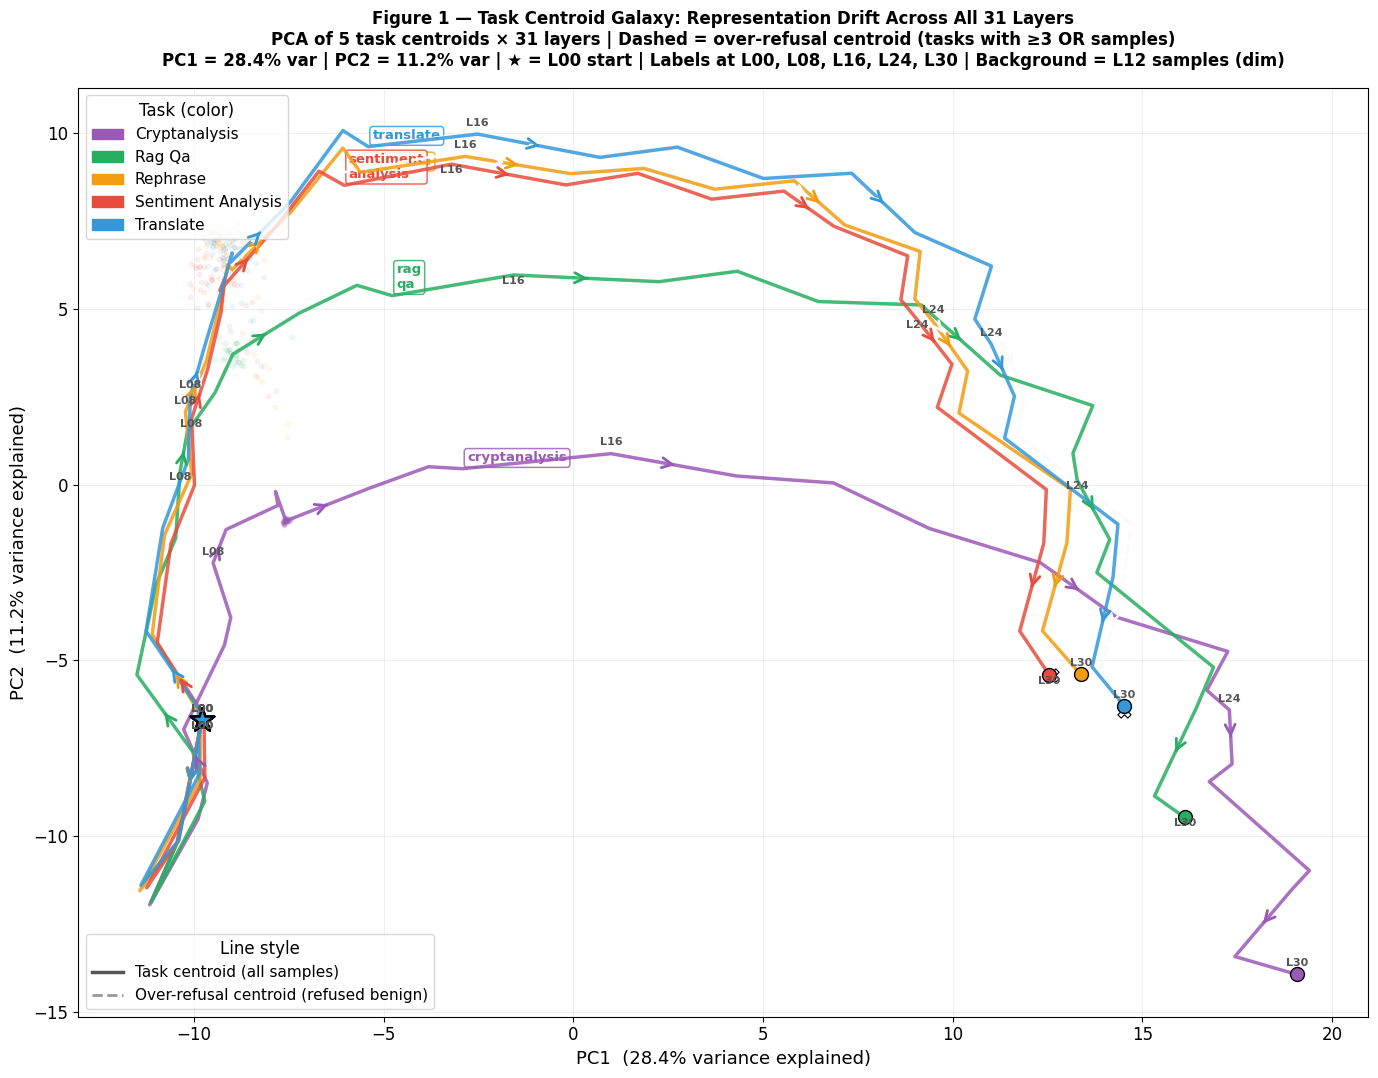

Saved: fig1_centroid_galaxy.pdf


In [6]:
# ── FIGURE 1 — Task Centroid Galaxy (ALL layers + over-refusal trajectories) ──
import colorsys

def lighten_hex(hex_color, factor=0.45):
    """Return a lighter/muted version of a hex color for over-refusal lines."""
    hex_color = hex_color.lstrip('#')
    r, g, b = [int(hex_color[i:i+2], 16) / 255.0 for i in (0, 2, 4)]
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = min(1.0, l + factor)
    s = max(0.0, s - 0.25)
    r2, g2, b2 = colorsys.hls_to_rgb(h, l, s)
    return '#{:02x}{:02x}{:02x}'.format(int(r2*255), int(g2*255), int(b2*255))

OR_TASK_COLORS = {task: lighten_hex(TASK_COLORS[task]) for task in ALL_TASKS}

# Layers to annotate with labels (every 8 + last)
LABEL_LAYERS = sorted(set([0, 8, 16, 24, FIG1_LAYERS[-1]]))
# Layers to draw arrows (every 4)
ARROW_EVERY  = 4

fig, ax = plt.subplots(figsize=(14, 11))

# Background: L12 samples in PCA space (very dim — structural context only)
for task in ALL_TASKS:
    tmask = intended_task_labels == task
    ax.scatter(l12_pca_2d[tmask, 0], l12_pca_2d[tmask, 1],
               c=TASK_COLORS[task], s=10, alpha=0.07, rasterized=True, zorder=1)

for ti, task in enumerate(ALL_TASKS):
    color    = TASK_COLORS[task]
    or_color = OR_TASK_COLORS[task]
    traj     = centroid_2d[ti]   # (N_FIG1, 2)

    # ── Solid: task centroid trajectory ──────────────────────────────────────
    ax.plot(traj[:, 0], traj[:, 1], color=color, lw=2.5, alpha=0.85, zorder=5,
            solid_capstyle='round', solid_joinstyle='round')

    # Arrows every ARROW_EVERY layers
    for j in range(0, N_FIG1 - 1, ARROW_EVERY):
        mid_x = (traj[j, 0] + traj[j+1, 0]) / 2
        mid_y = (traj[j, 1] + traj[j+1, 1]) / 2
        dx = traj[j+1, 0] - traj[j, 0]
        dy = traj[j+1, 1] - traj[j, 1]
        ax.annotate('', xy=(mid_x + dx*0.01, mid_y + dy*0.01),
                    xytext=(mid_x - dx*0.01, mid_y - dy*0.01),
                    arrowprops=dict(arrowstyle='->', color=color,
                                   lw=2.0, mutation_scale=18), zorder=6)

    # Start star + end circle
    ax.scatter(*traj[0],  c=color, s=320, zorder=12, marker='*',
               edgecolors='black', linewidths=1.6)
    ax.scatter(*traj[-1], c=color, s=100, zorder=10, marker='o',
               edgecolors='black', linewidths=1.0)

    # Layer labels at key positions
    for li in LABEL_LAYERS:
        ji = FIG1_LAYERS.index(li) if li in FIG1_LAYERS else None
        if ji is None:
            continue
        pt = traj[ji]
        offset_y = 0.18 if ti % 2 == 0 else -0.30
        ax.text(pt[0], pt[1] + offset_y, f'L{li:02d}',
                fontsize=8, ha='center', va='bottom', color='#555',
                fontweight='bold', zorder=13)

    # Task label near the midpoint (L16 ≈ middle)
    mid_ji  = min(N_FIG1 // 2, N_FIG1 - 1)
    lx, ly  = traj[mid_ji]
    ax.text(lx + 0.12, ly + 0.12,
            task.replace('_', '\n'),
            fontsize=9.5, color=color, fontweight='bold', va='bottom',
            bbox=dict(boxstyle='round,pad=0.22', facecolor='white',
                      alpha=0.82, edgecolor=color, linewidth=1.1))

    # ── Dashed: over-refusal centroid trajectory (if available) ──────────────
    if task not in or_centroid_2d:
        continue
    or_traj = or_centroid_2d[task]   # (N_FIG1, 2)

    ax.plot(or_traj[:, 0], or_traj[:, 1], color=or_color, lw=2.0, alpha=0.90,
            ls='--', zorder=4, solid_capstyle='round', solid_joinstyle='round')

    # Arrows every ARROW_EVERY layers
    for j in range(0, N_FIG1 - 1, ARROW_EVERY):
        mid_x = (or_traj[j, 0] + or_traj[j+1, 0]) / 2
        mid_y = (or_traj[j, 1] + or_traj[j+1, 1]) / 2
        dx = or_traj[j+1, 0] - or_traj[j, 0]
        dy = or_traj[j+1, 1] - or_traj[j, 1]
        ax.annotate('', xy=(mid_x + dx*0.01, mid_y + dy*0.01),
                    xytext=(mid_x - dx*0.01, mid_y - dy*0.01),
                    arrowprops=dict(arrowstyle='->', color=or_color,
                                   lw=1.8, mutation_scale=15), zorder=5)

    # Start X + end X
    ax.scatter(*or_traj[0],  c=or_color, s=280, zorder=11, marker='*',
               edgecolors='black', linewidths=1.4)
    ax.scatter(*or_traj[-1], c=or_color, s=90,  zorder=9,  marker='X',
               edgecolors='black', linewidths=0.8)

# ── Legends ───────────────────────────────────────────────────────────────────
task_handles = [mpatches.Patch(color=TASK_COLORS[t],
                label=t.replace('_', ' ').title()) for t in ALL_TASKS]
style_handles = [
    plt.Line2D([0], [0], color='#555', lw=2.5, ls='-',
               label='Task centroid (all samples)'),
    plt.Line2D([0], [0], color='#999', lw=2.0, ls='--',
               label='Over-refusal centroid (refused benign)'),
]
l1 = ax.legend(handles=task_handles, loc='upper left', fontsize=11, frameon=True,
               fancybox=True, title='Task (color)', title_fontsize=12)
ax.legend(handles=style_handles, loc='lower left', fontsize=11, frameon=True,
          fancybox=True, title='Line style', title_fontsize=12)
ax.add_artist(l1)

label_str = ', '.join([f'L{l:02d}' for l in LABEL_LAYERS])
ax.set_title(
    f'Figure 1 — Task Centroid Galaxy: Representation Drift Across All {N_FIG1} Layers\n'
    f'PCA of 5 task centroids × {N_FIG1} layers | Dashed = over-refusal centroid (tasks with ≥3 OR samples)\n'
    f'PC1 = {var_pc1:.1f}% var | PC2 = {var_pc2:.1f}% var | '
    f'★ = L00 start | Labels at {label_str} | Background = L12 samples (dim)',
    fontsize=12, fontweight='bold', pad=16)
ax.set_xlabel(f'PC1  ({var_pc1:.1f}% variance explained)', fontsize=13)
ax.set_ylabel(f'PC2  ({var_pc2:.1f}% variance explained)', fontsize=13)
ax.grid(True, alpha=0.20)

plt.tight_layout()
plt.savefig('fig1_centroid_galaxy.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig1_centroid_galaxy.pdf')

---
## Figure 2 — Within-Task Behavior Trajectories

**What this is:** For the 3 tasks that have over-refusal data (rephrase, sentiment_analysis, translate), we show how the **target-behavior centroid** (answered, solid line) and the **over-refusal centroid** (refused benign, dashed line) move across layers — in a shared L12-anchored UMAP space.

**How to read it:** Background = all L12 samples (grey = this task's cloud). Green solid = where the model keeps correctly answering. Red dashed = where it incorrectly refuses. The gap between these paths is the geometric signature of over-refusal.

**Caveat:** Layers far from L12 are projected via UMAP transform, which is approximate. Centroid positions (averaged over many samples) are more stable than individual point projections.

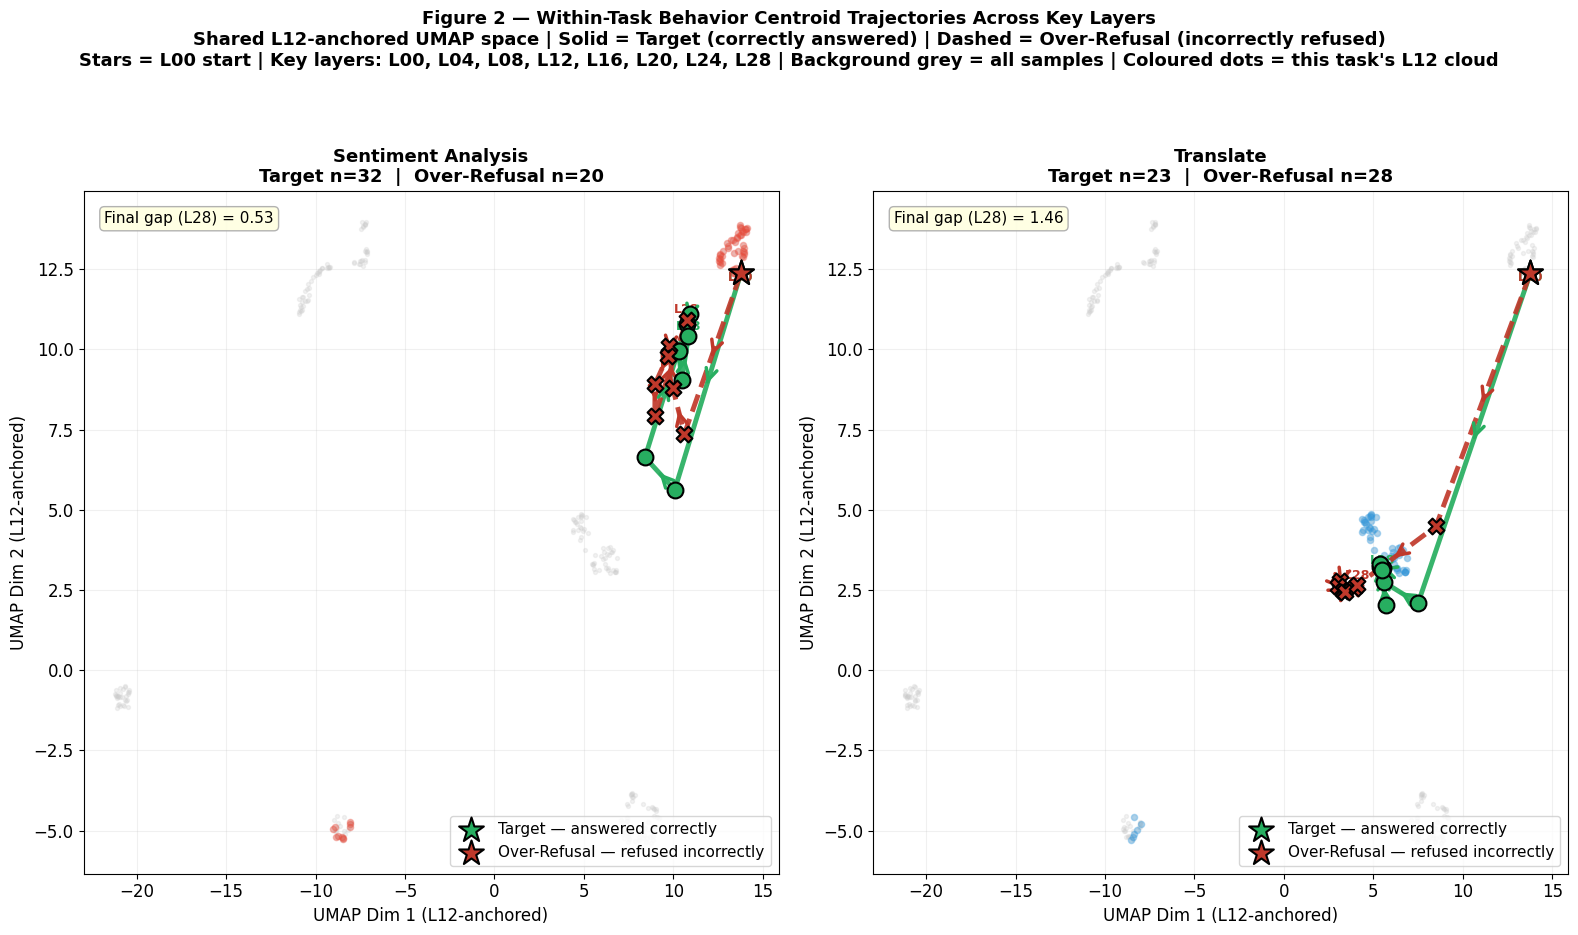

Saved: fig2_behavior_trajectories.pdf


In [7]:
# ── FIGURE 2 — Within-Task Behavior Centroid Trajectories ────────────────────
n_panels = len(TASKS_WITH_OR)
fig, axes = plt.subplots(1, n_panels, figsize=(8 * n_panels, 9))
if n_panels == 1:
    axes = [axes]

TARGET_COLOR   = '#27AE60'   # green — answered correctly
OR_COLOR       = '#C0392B'   # red   — refused incorrectly

for ax, task in zip(axes, TASKS_WITH_OR):
    task_color = TASK_COLORS[task]
    tmask      = intended_task_labels == task

    # Background: all L12 samples (full dataset, very dim)
    ax.scatter(umap_l12[:, 0], umap_l12[:, 1],
               c='#cccccc', s=8, alpha=0.25, rasterized=True, zorder=1)

    # This task's L12 samples (slightly more visible)
    ax.scatter(umap_l12[tmask, 0], umap_l12[tmask, 1],
               c=task_color, s=20, alpha=0.35, rasterized=True, zorder=2)

    for beh, color, ls, mshape, label_str in [
        ('target',       TARGET_COLOR, '-',  'o', 'Target — answered correctly'),
        ('over_refusal', OR_COLOR,     '--', 'X', 'Over-Refusal — refused incorrectly'),
    ]:
        key = (task, beh)
        if key not in beh_cents:
            continue
        traj = beh_cents[key]   # (N_FIG2, 2)

        # Line
        ax.plot(traj[:, 0], traj[:, 1], color=color, lw=3.5, ls=ls,
                alpha=0.92, zorder=5, solid_capstyle='round')

        # Arrows at midpoints
        for j in range(N_FIG2 - 1):
            mid = (traj[j] + traj[j+1]) / 2
            delta = traj[j+1] - traj[j]
            ax.annotate('',
                xy=mid + delta * 0.01, xytext=mid - delta * 0.01,
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=2.5, mutation_scale=20), zorder=6)

        # Waypoint markers
        for j, pt in enumerate(traj):
            s = 350 if j == 0 else 130
            m = '*'  if j == 0 else mshape
            ax.scatter(*pt, c=color, s=s, marker=m, zorder=10,
                       edgecolors='black', linewidths=1.5,
                       label=label_str if j == 0 else '')

        # Layer labels at start and end
        ax.text(traj[0, 0], traj[0, 1] - 0.25, f'L{FIG2_LAYERS[0]:02d}',
                fontsize=9, ha='center', color=color, fontweight='bold')
        ax.text(traj[-1, 0], traj[-1, 1] + 0.20, f'L{FIG2_LAYERS[-1]:02d}',
                fontsize=9, ha='center', color=color, fontweight='bold')

    # Distance between final centroids
    if (task, 'target') in beh_cents and (task, 'over_refusal') in beh_cents:
        tgt_end = beh_cents[(task, 'target')][-1]
        or_end  = beh_cents[(task, 'over_refusal')][-1]
        dist    = np.linalg.norm(tgt_end - or_end)
        ax.text(0.03, 0.97, f'Final gap (L{FIG2_LAYERS[-1]:02d}) = {dist:.2f}',
                transform=ax.transAxes, fontsize=11, va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                          alpha=0.9, edgecolor='#aaa'))

    n_tgt = (tmask & TARGET_MASK).sum()
    n_or  = (tmask & OVER_REFUSAL_MASK).sum()
    ax.set_title(
        f'{task.replace("_", " ").title()}\n'
        f'Target n={n_tgt}  |  Over-Refusal n={n_or}',
        fontsize=13, fontweight='bold')
    ax.set_xlabel('UMAP Dim 1 (L12-anchored)', fontsize=12)
    ax.set_ylabel('UMAP Dim 2 (L12-anchored)', fontsize=12)
    ax.legend(fontsize=11, frameon=True, loc='lower right')
    ax.grid(True, alpha=0.18)

key_layer_str = ', '.join([f'L{l:02d}' for l in FIG2_LAYERS])
fig.suptitle(
    'Figure 2 — Within-Task Behavior Centroid Trajectories Across Key Layers\n'
    'Shared L12-anchored UMAP space | Solid = Target (correctly answered) | '
    'Dashed = Over-Refusal (incorrectly refused)\n'
    f'Stars = L00 start | Key layers: {key_layer_str} | '
    'Background grey = all samples | Coloured dots = this task\'s L12 cloud',
    fontsize=13, fontweight='bold', y=1.04)

plt.tight_layout()
plt.savefig('fig2_behavior_trajectories.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig2_behavior_trajectories.pdf')

---
## Figure 3 — Honest L12 Snapshot

**What this is:** The raw per-layer UMAP of all 270 samples at L12 — the peak constellation layer. Unlike NB5's centroid-trajectory plots, nothing is filtered or aggregated. This is what the actual data looks like.

**Color = task.** Marker shape = behavioral class (circle = target, X = over-refusal, square = refused-harmful, dot = other). Large ★ = task centroid.

**Comparison to NB5:** NB5 plotted centroid trajectories and filtered to 1.5σ core samples — the visually clean result was partly methodological. This figure shows the true point-cloud separation.

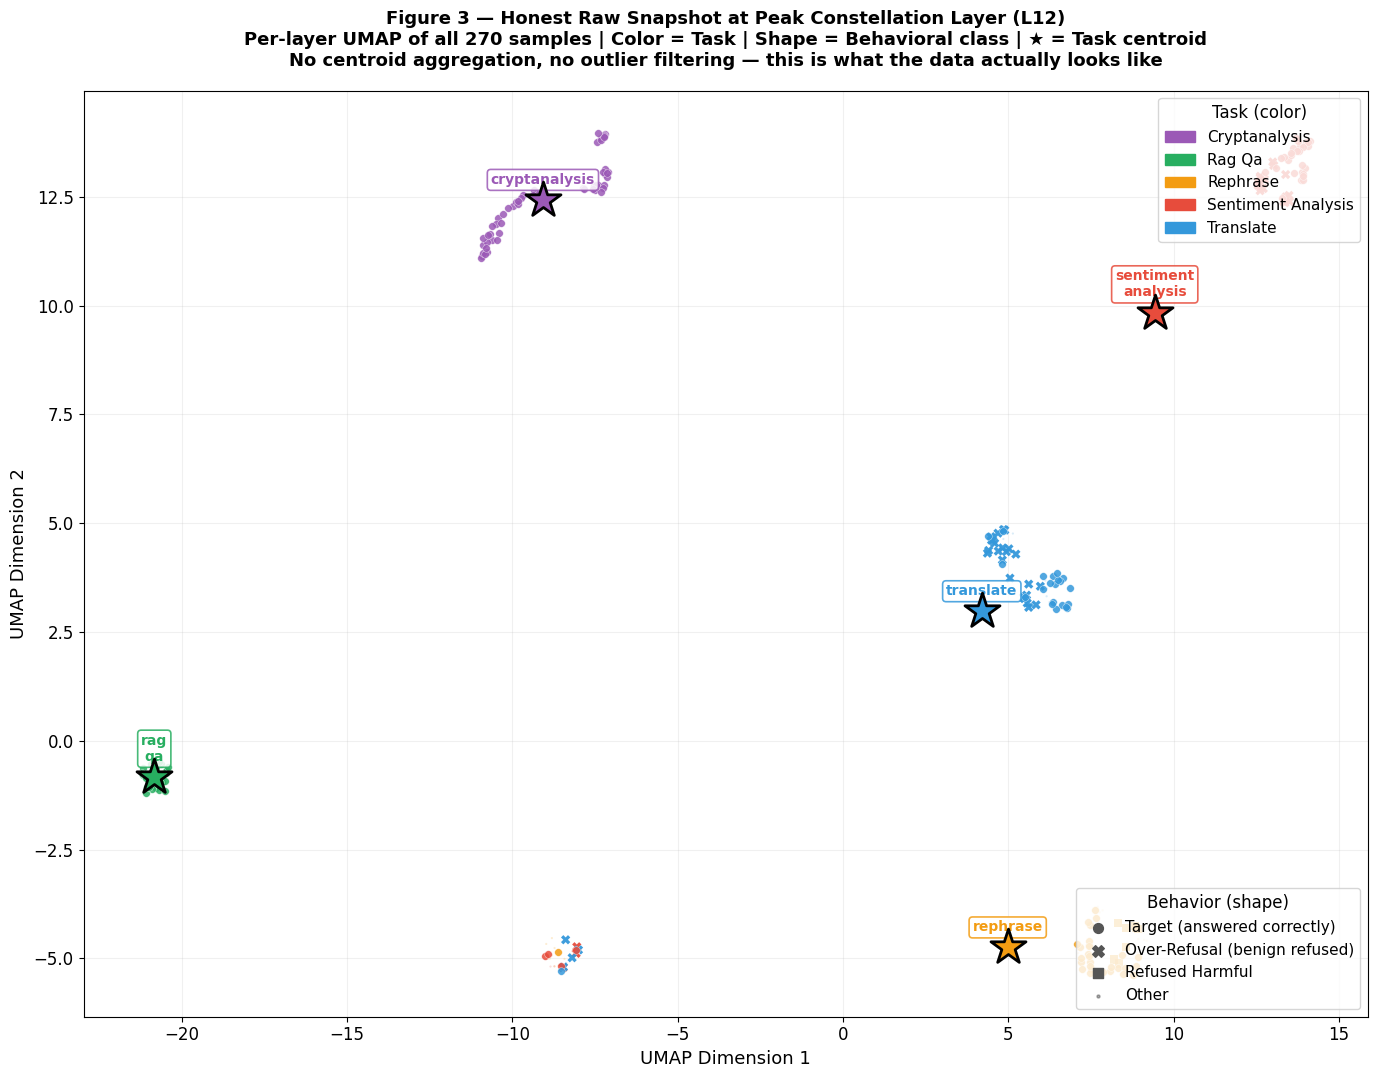

Saved: fig3_l12_honest_scatter.pdf


In [8]:
# ── FIGURE 3 — Honest L12 Snapshot ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))

BEH_PLOT_ORDER = ['other', 'refused_harmful', 'over_refusal', 'target']

for beh in BEH_PLOT_ORDER:
    bmask = beh_labels == beh
    for task in ALL_TASKS:
        mask = bmask & (intended_task_labels == task)
        if mask.sum() == 0:
            continue
        ax.scatter(
            umap_l12[mask, 0], umap_l12[mask, 1],
            c=TASK_COLORS[task],
            marker=BEH_MARKERS[beh],
            s=BEH_SIZES[beh],
            alpha=BEH_ALPHA[beh],
            linewidths=0.3,
            edgecolors='white' if beh == 'target' else 'none',
            rasterized=True, zorder=3,
        )

# Large centroid stars per task
for task in ALL_TASKS:
    tmask  = intended_task_labels == task
    cx, cy = umap_l12[tmask].mean(axis=0)
    ax.scatter(cx, cy, c=TASK_COLORS[task], s=700, marker='*', zorder=12,
               edgecolors='black', linewidths=2.0)
    ax.text(cx, cy + 0.30, task.replace('_', '\n'),
            fontsize=10, ha='center', va='bottom', fontweight='bold',
            color=TASK_COLORS[task],
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                      alpha=0.85, edgecolor=TASK_COLORS[task], linewidth=1.2))

# Legends
task_handles = [
    mpatches.Patch(color=TASK_COLORS[t], label=t.replace('_', ' ').title())
    for t in ALL_TASKS
]
beh_handles = [
    plt.scatter([], [], c='#555', marker=BEH_MARKERS['target'],
                s=50, label='Target (answered correctly)'),
    plt.scatter([], [], c='#555', marker=BEH_MARKERS['over_refusal'],
                s=70, label='Over-Refusal (benign refused)'),
    plt.scatter([], [], c='#555', marker=BEH_MARKERS['refused_harmful'],
                s=50, label='Refused Harmful'),
    plt.scatter([], [], c='#555', marker=BEH_MARKERS['other'],
                s=18, label='Other', alpha=0.5),
]
l1 = ax.legend(handles=task_handles, loc='upper right',
               title='Task (color)', title_fontsize=12, fontsize=11, frameon=True)
ax.legend(handles=beh_handles, loc='lower right',
          title='Behavior (shape)', title_fontsize=12, fontsize=11, frameon=True)
ax.add_artist(l1)

ax.set_title(
    'Figure 3 — Honest Raw Snapshot at Peak Constellation Layer (L12)\n'
    'Per-layer UMAP of all 270 samples | Color = Task | Shape = Behavioral class | '
    '★ = Task centroid\n'
    'No centroid aggregation, no outlier filtering — this is what the data actually looks like',
    fontsize=13, fontweight='bold', pad=18)
ax.set_xlabel('UMAP Dimension 1', fontsize=13)
ax.set_ylabel('UMAP Dimension 2', fontsize=13)
ax.grid(True, alpha=0.18)

plt.tight_layout()
plt.savefig('fig3_l12_honest_scatter.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig3_l12_honest_scatter.pdf')

In [9]:
# ── Numeric summary ───────────────────────────────────────────────────────────
print('=' * 68)
print('CONSTELLATION CENTROID MAP — NUMERIC SUMMARY')
print('=' * 68)

print('\n[1] CENTROID DISPLACEMENT (L00 → last layer, high-dim Euclidean)')
print(f'    {"Task":<22} {"Displacement":>14}')
print(f'    {"-"*40}')
for ti, task in enumerate(ALL_TASKS):
    c_start = centroid_hd[ti, 0]
    c_end   = centroid_hd[ti, -1]
    disp    = float(np.linalg.norm(c_end - c_start))
    print(f'    {task:<22} {disp:>14.2f}')

print('\n[2] INTER-TASK CENTROID DISTANCES AT KEY LAYERS (high-dim)')
print(f'    {"Layer":<6}  {"Mean pairwise dist":>20}  {"Min pair":>12}  {"Max pair":>12}')
print(f'    {"-"*55}')
for ji, (li, lname) in enumerate(zip(FIG2_LAYERS, FIG2_LNAMES)):
    # find index in FIG1 arrays (same layer order)
    fi = FIG1_LAYERS.index(li) if li in FIG1_LAYERS else ji
    dists = []
    for ti1, t1 in enumerate(ALL_TASKS):
        for ti2, t2 in enumerate(ALL_TASKS):
            if ti1 < ti2:
                dists.append(float(np.linalg.norm(centroid_hd[ti1, fi] - centroid_hd[ti2, fi])))
    print(f'    L{li:02d}    {np.mean(dists):>20.2f}  {np.min(dists):>12.2f}  {np.max(dists):>12.2f}')

print('\n[3] BEHAVIOR GAP (target vs over-refusal centroid, L12 UMAP space)')
print(f'    {"Task":<22} {"Gap at L00":>12} {"Gap at L12":>12} {"Gap at L28":>12}')
print(f'    {"-"*62}')
l00_idx = 0
l12_idx = FIG2_LAYERS.index(12) if 12 in FIG2_LAYERS else N_FIG2 // 2
l28_idx = FIG2_LAYERS.index(28) if 28 in FIG2_LAYERS else N_FIG2 - 1
for task in TASKS_WITH_OR:
    tgt = beh_cents.get((task, 'target'))
    orl = beh_cents.get((task, 'over_refusal'))
    if tgt is None or orl is None:
        print(f'    {task:<22}  insufficient data')
        continue
    g00 = np.linalg.norm(tgt[l00_idx] - orl[l00_idx])
    g12 = np.linalg.norm(tgt[l12_idx] - orl[l12_idx])
    g28 = np.linalg.norm(tgt[l28_idx] - orl[l28_idx])
    print(f'    {task:<22} {g00:>12.3f} {g12:>12.3f} {g28:>12.3f}')

print('\n[4] SAVED FIGURES')
for f in ['fig1_centroid_galaxy.pdf', 'fig2_behavior_trajectories.pdf',
          'fig3_l12_honest_scatter.pdf']:
    status = '[OK]' if os.path.exists(f) else '[MISSING]'
    print(f'    {f:<45} {status}')

print('=' * 68)

CONSTELLATION CENTROID MAP — NUMERIC SUMMARY

[1] CENTROID DISPLACEMENT (L00 → last layer, high-dim Euclidean)
    Task                     Displacement
    ----------------------------------------
    cryptanalysis                   38.67
    rag_qa                          35.19
    rephrase                        32.58
    sentiment_analysis              32.00
    translate                       33.24

[2] INTER-TASK CENTROID DISTANCES AT KEY LAYERS (high-dim)
    Layer     Mean pairwise dist      Min pair      Max pair
    -------------------------------------------------------
    L00                    0.00          0.00          0.00
    L04                    9.04          3.56         13.25
    L08                   17.47          7.86         25.32
    L12                   20.12          9.74         27.27
    L16                   19.98          9.87         26.73
    L20                   18.81         10.24         25.57
    L24                   18.05         10.34      